In [2]:
# UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks
# than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
import os
os.environ["OMP_NUM_THREADS"] = '2'

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#######################################
# 1. load dataframe
#
data = pd.read_csv('Wholesale-customers-data.csv')
data.head(2)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776


In [3]:
#######################################
# 2. get keys
#
keys = data.keys().tolist()
print(keys)
data.get(keys[1])

['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


0      3
1      3
2      3
3      3
4      3
      ..
435    3
436    3
437    3
438    3
439    3
Name: Region, Length: 440, dtype: int64

In [4]:
#######################################
# 3 (1/2). Count nulls
#
data.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [5]:
#######################################
# 3 (2/2). Count nulls
#
for key in keys:
    count = data.get(key).isnull().sum()
    print(key, 'null count', count)

Channel null count 0
Region null count 0
Fresh null count 0
Milk null count 0
Grocery null count 0
Frozen null count 0
Detergents_Paper null count 0
Delicassen null count 0


In [6]:
#######################################
# 4. Count distinct values
#
for key in keys:
    values = data[key].value_counts()
    # print(key, values)

In [7]:
#######################################
# 5 Check outliers
#

data_without_outliers = data.copy()
outliers = {}

for key in keys:
    col = data_without_outliers[key]
    min_deviation = col.mean() - 3 * col.std()
    max_deviation = col.mean() + 3 * col.std()
    min_outlier_count = col[col < min_deviation].count()
    max_outlier_count = col[col > max_deviation].count()
    subtotal = min_outlier_count + max_outlier_count
    outliers[key] = [subtotal, (data.shape[0] - subtotal)]

    data_without_outliers = data_without_outliers[(col >= min_deviation) & (col <= max_deviation)]

print('outliers', outliers)

data_without_outliers.shape

outliers {'Channel': [0, 440], 'Region': [0, 440], 'Fresh': [7, 433], 'Milk': [8, 432], 'Grocery': [7, 433], 'Frozen': [5, 435], 'Detergents_Paper': [11, 429], 'Delicassen': [6, 434]}


(396, 8)

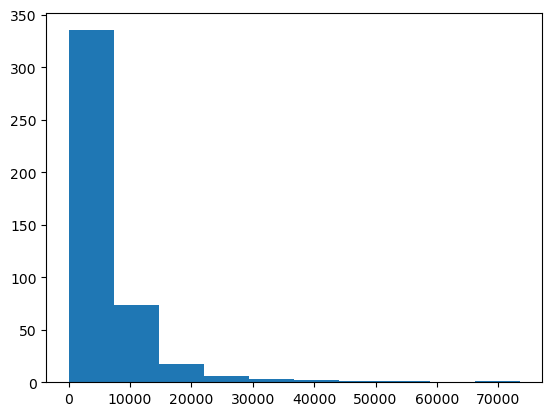

In [8]:
#######################################
# 6. Hist graph
#

plt.hist(data['Milk'])
plt.show()

440 10


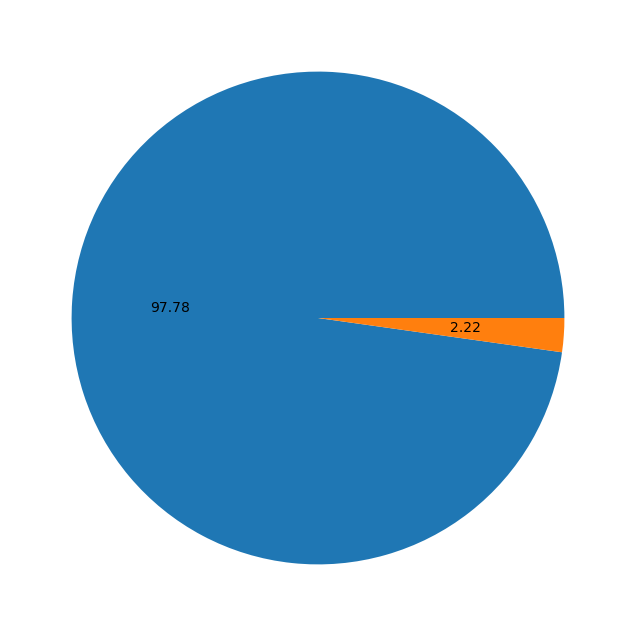

In [9]:
#######################################
# 7. Pie chart
#

attribute = 'Detergents_Paper'
col = data[attribute]
min_deviation = col.mean() - 3 * col.std()
max_deviation = col.mean() + 3 * col.std()
outliers = col[(col < min_deviation) | (col > max_deviation)]
print(col.shape[0], outliers.count())

plt.figure(figsize=(8, 8))
plt.pie([col.shape[0], outliers.count()], autopct='%.2f')
plt.show()


In [10]:
#######################################
# 8. Normalization/Standardization
#    Q: Why not use `data_without_outliers`?

# data_without_outliers = (data_without_outliers - data_without_outliers.mean()) / data_without_outliers.std()
# print(data_without_outliers.head(10))

data_standardized = (data - data.mean()) / data.std()
print(data_standardized.head(10))

    Channel    Region     Fresh      Milk   Grocery    Frozen  \
0  1.447005  0.589997  0.052873  0.522972 -0.041068 -0.588697   
1  1.447005  0.589997 -0.390857  0.543839  0.170125 -0.269829   
2  1.447005  0.589997 -0.446521  0.408073 -0.028125 -0.137379   
3 -0.689512  0.589997  0.099998 -0.623310 -0.392530  0.686363   
4  1.447005  0.589997  0.839284 -0.052337 -0.079266  0.173661   
5  1.447005  0.589997 -0.204573  0.333687 -0.297299 -0.495591   
6  1.447005  0.589997  0.009939 -0.351915 -0.102732 -0.533904   
7  1.447005  0.589997 -0.349584 -0.113851  0.155182 -0.288986   
8 -0.689512  0.589997 -0.477358 -0.291078 -0.185125 -0.545234   
9  1.447005  0.589997 -0.473958  0.717678  1.150114 -0.394039   

   Detergents_Paper  Delicassen  
0         -0.043519   -0.066264  
1          0.086309    0.089050  
2          0.133080    2.240742  
3         -0.498021    0.093305  
4         -0.231654    1.297870  
5         -0.227879   -0.026194  
6          0.054219   -0.347459  
7          0

In [11]:
#######################################
# 9. Import k-means library
#

from sklearn.cluster import KMeans

In [12]:
#######################################
# 10. Calculate average distance of data points from its centroids
#

max_clusters = 20;
ideal_k = []

for i in range(1, max_clusters + 1):
    est_kmeans = KMeans(n_clusters = i, random_state = 0)
    est_kmeans.fit(data_standardized)
    ideal_k.append([i, est_kmeans.inertia_])

ideal_k = np.array(ideal_k)

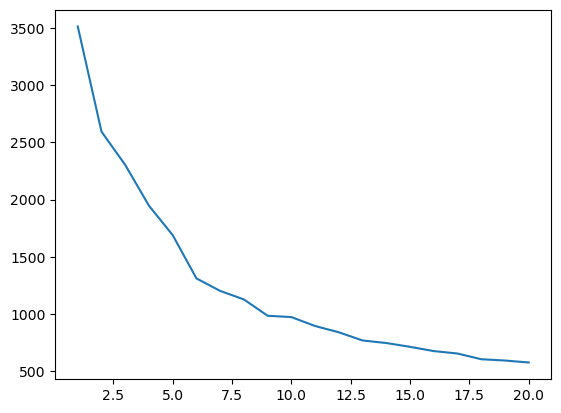

In [13]:
#######################################
# 11. Plot "number of clusters" vs "average distance to controid in clusters"
#

plt.plot(ideal_k[:, 0], ideal_k[:, 1])
plt.show()

In [14]:
#######################################
# 12. The breaking point of number of clusters is 6
#     Use "number of clusters" = 6 to tran the model
#
est_kmeans = KMeans(n_clusters = 6, random_state = 0)
est_kmeans.fit(data_standardized)
pred_kmeans = est_kmeans.predict(data_standardized)

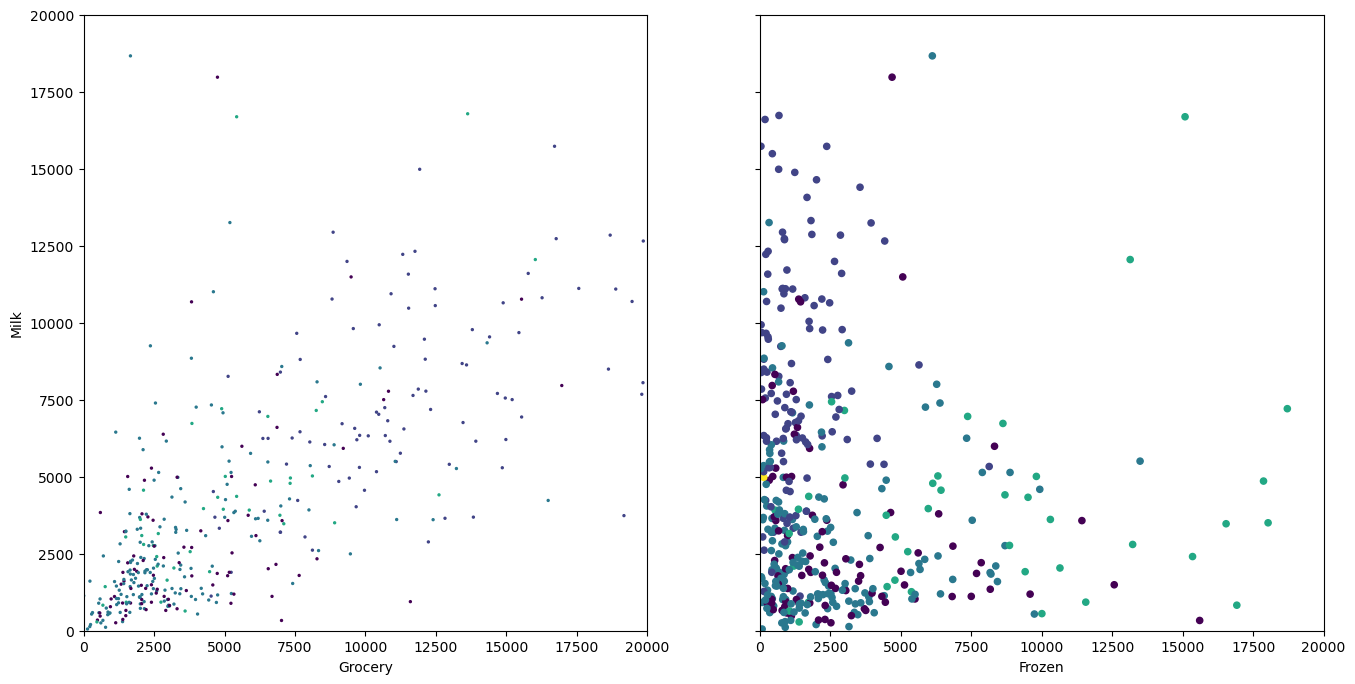

In [15]:
#######################################
# 13. Plot clustering result
#

plt.subplots(1, 2, sharex = 'col', sharey = 'row', figsize = (16, 8))
plt.scatter(data.iloc[:, 5], data.iloc[:, 3], c = pred_kmeans, s = 20)
plt.xlim([0, 20_000])
plt.ylim([0, 20_000])
plt.xlabel('Frozen')
plt.subplot(1, 2, 1)
plt.scatter(data.iloc[:, 4], data.iloc[:, 3], c = pred_kmeans, s = 2.0)
plt.xlim([0, 20_000])
plt.ylim([0, 20_000])
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()

In [16]:
#######################################
# 13. MeanShift
#

from sklearn.cluster import MeanShift

In [17]:
#######################################
# 14. fit/predict
#

est_meanshift = MeanShift(bandwidth = 0.4)
est_meanshift.fit(data_standardized)
pred_meanshift = est_meanshift.predict(data_standardized)

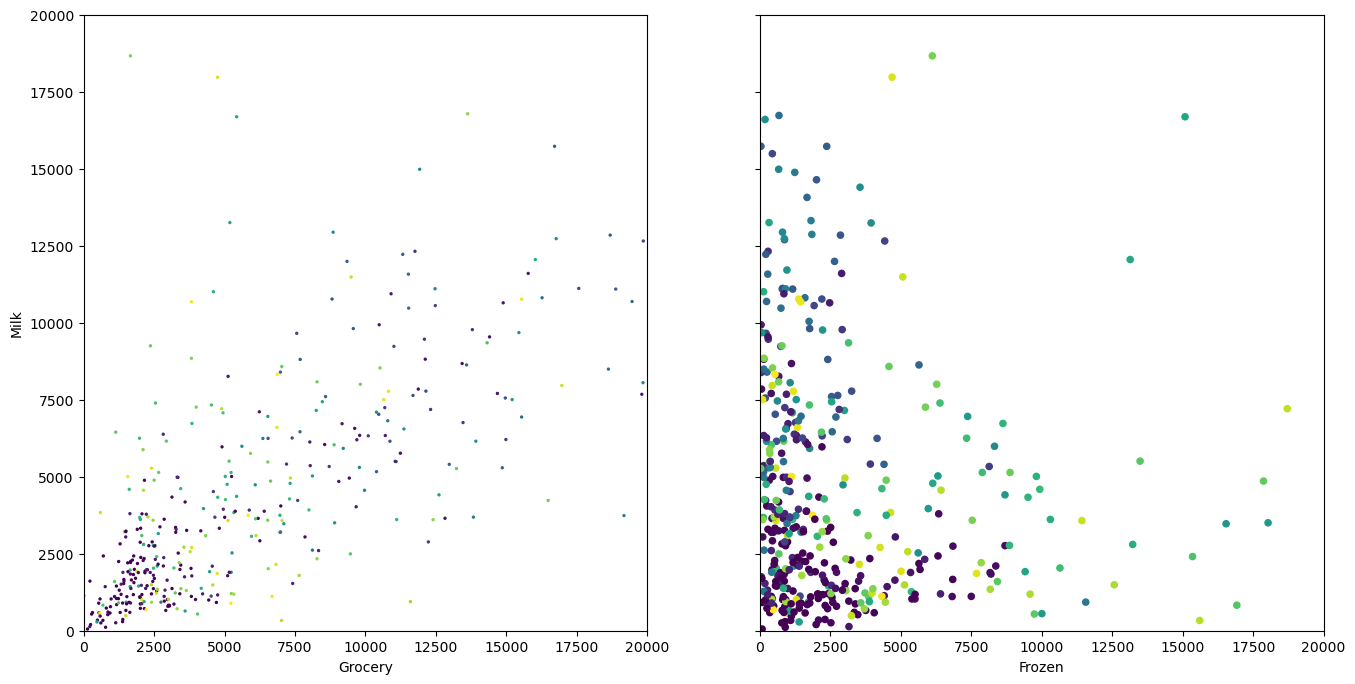

In [18]:
#######################################
# 15. fit/predict
#

plt.subplots(1, 2, sharex = 'col', sharey = 'row', figsize = (16, 8))
plt.scatter(data.iloc[:, 5], data.iloc[:, 3], c = pred_meanshift, s = 20)
plt.xlim([0, 20_000])
plt.ylim([0, 20_000])
plt.xlabel('Frozen')
plt.subplot(1, 2, 1)
plt.scatter(data.iloc[:, 4], data.iloc[:, 3], c = pred_meanshift, s = 2.0)
plt.xlim([0, 20_000])
plt.ylim([0, 20_000])
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()